# Analisis Predictivo del Rendimiento en Tenis Profesional

Este proyecto analiza estadisticas de rendimiento de tenistas profesionales para identificar los factores que mas influyen en las ganancias monetarias (prize money) y construir modelos predictivos usando regresion lineal simple y multiple.

**Objetivos:**
1. Explorar las relaciones entre estadisticas de juego y ganancias
2. Identificar las variables mas correlacionadas con el exito economico
3. Comparar modelos de regresion simple vs multiple
4. Evaluar la capacidad predictiva de los modelos

**Dataset:** 1,721 registros de tenistas profesionales con 23 variables de rendimiento.

## 1. Importacion y Exploracion de Datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 12

df = pd.read_csv('tennis_stats.csv')
print(f"Dataset: {df.shape[0]} registros, {df.shape[1]} variables")
print(f"Jugadores unicos: {df['Player'].nunique()}")
print(f"Periodo: {df['Year'].min()} - {df['Year'].max()}")
print()
df.head()

Dataset: 1721 registros, 24 variables
Jugadores unicos: 438
Periodo: 2009 - 2017



,Player,Year,FirstServe,FirstServePointsWon,FirstServeReturnPointsWon,SecondServePointsWon,SecondServeReturnPointsWon,Aces,BreakPointsConverted,BreakPointsFaced,...,ReturnGamesWon,ReturnPointsWon,ServiceGamesPlayed,ServiceGamesWon,TotalPointsWon,TotalServicePointsWon,Wins,Losses,Winnings,Ranking
0,Pedro Sousa,2016,0.88,0.50,0.38,0.50,0.39,0,0.14,7,...,0.11,0.38,8,0.50,0.43,0.50,1,2,39820,119
1,Roman Safiullin,2017,0.84,0.62,0.26,0.33,0.07,7,0.00,7,...,0.00,0.20,9,0.67,0.41,0.57,0,1,17334,381
2,Pedro Sousa,2017,0.83,0.60,0.28,0.53,0.44,2,0.38,10,...,0.16,0.34,17,0.65,0.45,0.59,4,1,109827,119
3,Rogerio Dutra Silva,2010,0.83,0.64,0.34,0.59,0.33,2,0.33,5,...,0.14,0.34,15,0.80,0.49,0.63,0,0,9761,125
4,Daniel Gimeno-Traver,2017,0.81,0.54,0.00,0.33,0.33,1,0.00,2,...,0.00,0.20,2,0.50,0.35,0.50,0,1,32879,272


In [2]:
# Estadisticas descriptivas de variables clave
key_stats = ['Wins', 'Losses', 'Aces', 'DoubleFaults', 'BreakPointsConverted', 
             'Ranking', 'Winnings']
print("=" * 70)
print("ESTADISTICAS DESCRIPTIVAS")
print("=" * 70)
df[key_stats].describe().round(2)

ESTADISTICAS DESCRIPTIVAS


,Wins,Losses,Aces,DoubleFaults,BreakPointsConverted,Ranking,Winnings
count,1721.00,1721.00,1721.00,1721.00,1721.00,1721.00,1721.00
mean,7.88,9.28,97.11,49.11,0.37,269.61,234492.76
std,10.18,9.00,137.97,56.63,0.16,277.34,253053.69
min,0.00,0.00,0.00,0.00,0.00,3.00,108.00
25%,0.00,2.00,7.00,6.00,0.32,83.00,49311.00
50%,3.00,5.00,34.00,23.00,0.38,166.00,125212.00
75%,13.00,17.00,140.00,80.00,0.43,333.00,350075.00
max,48.00,36.00,1185.00,309.00,1.00,1443.00,1074562.00


## 2. Analisis Exploratorio (EDA)

### 2.1 Distribucion de la variable objetivo

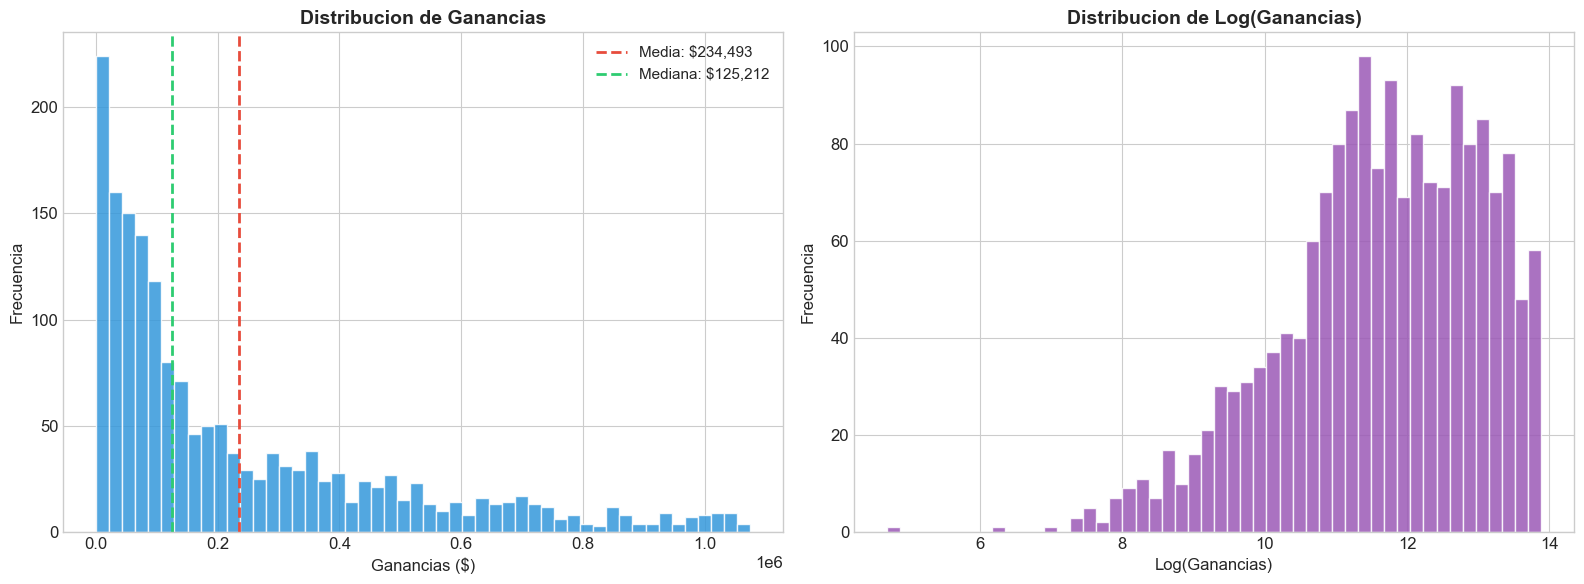

Sesgo (skewness): 1.41
La distribucion esta fuertemente sesgada: pocos jugadores ganan mucho.


In [3]:
# Distribucion de Winnings
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(df['Winnings'], bins=50, color='#3498db', edgecolor='white', alpha=0.85)
axes[0].axvline(df['Winnings'].mean(), color='#e74c3c', linestyle='--', linewidth=2,
               label=f"Media: ${df['Winnings'].mean():,.0f}")
axes[0].axvline(df['Winnings'].median(), color='#2ecc71', linestyle='--', linewidth=2,
               label=f"Mediana: ${df['Winnings'].median():,.0f}")
axes[0].set_title('Distribucion de Ganancias', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Ganancias ($)', fontsize=12)
axes[0].set_ylabel('Frecuencia', fontsize=12)
axes[0].legend(fontsize=11)

axes[1].hist(np.log1p(df['Winnings']), bins=50, color='#9b59b6', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribucion de Log(Ganancias)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Log(Ganancias)', fontsize=12)
axes[1].set_ylabel('Frecuencia', fontsize=12)

plt.tight_layout()
plt.show()

print(f"Sesgo (skewness): {df['Winnings'].skew():.2f}")
print("La distribucion esta fuertemente sesgada: pocos jugadores ganan mucho.")

### 2.2 Matriz de correlacion

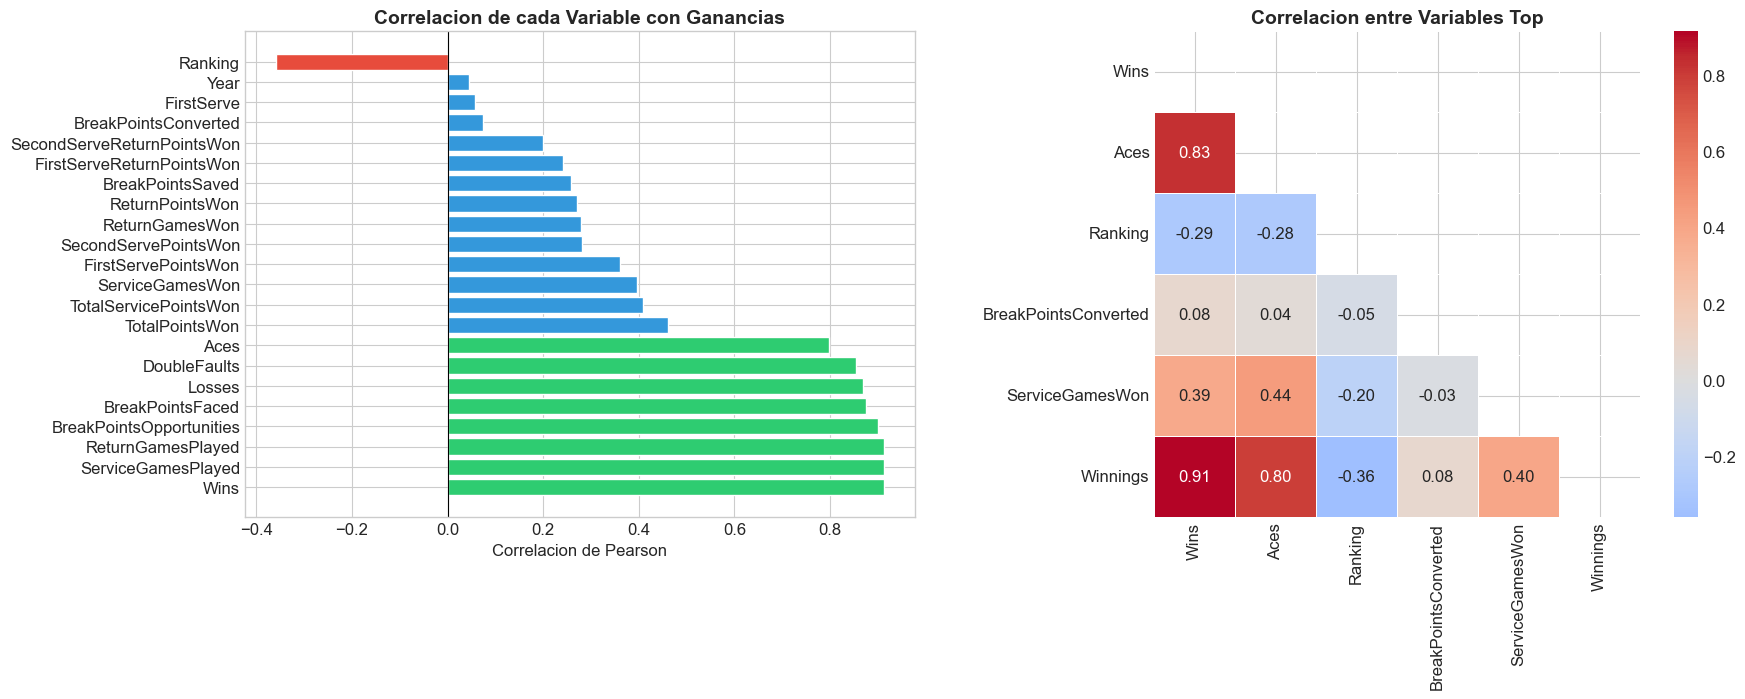

Variables mas correlacionadas con Ganancias:
  Wins: r = 0.913
  ServiceGamesPlayed: r = 0.913
  ReturnGamesPlayed: r = 0.913
  BreakPointsOpportunities: r = 0.900
  BreakPointsFaced: r = 0.876


In [4]:
# Correlacion de todas las variables numericas con Winnings
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
correlations = df[numeric_cols].corr()['Winnings'].drop('Winnings').sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Barplot de correlaciones
colors_corr = ['#2ecc71' if v > 0.5 else '#3498db' if v > 0 else '#e74c3c' for v in correlations]
axes[0].barh(correlations.index, correlations.values, color=colors_corr, edgecolor='white')
axes[0].set_title('Correlacion de cada Variable con Ganancias', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Correlacion de Pearson', fontsize=12)
axes[0].axvline(x=0, color='black', linewidth=0.8)

# Heatmap de variables top
top_vars = ['Wins', 'Aces', 'Ranking', 'BreakPointsConverted', 'ServiceGamesWon', 'Winnings']
mask = np.triu(np.ones_like(df[top_vars].corr(), dtype=bool))
sns.heatmap(df[top_vars].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, square=True, ax=axes[1], linewidths=0.5)
axes[1].set_title('Correlacion entre Variables Top', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("Variables mas correlacionadas con Ganancias:")
for var, corr in correlations.head(5).items():
    print(f"  {var}: r = {corr:.3f}")

### 2.3 Scatter plots de variables clave

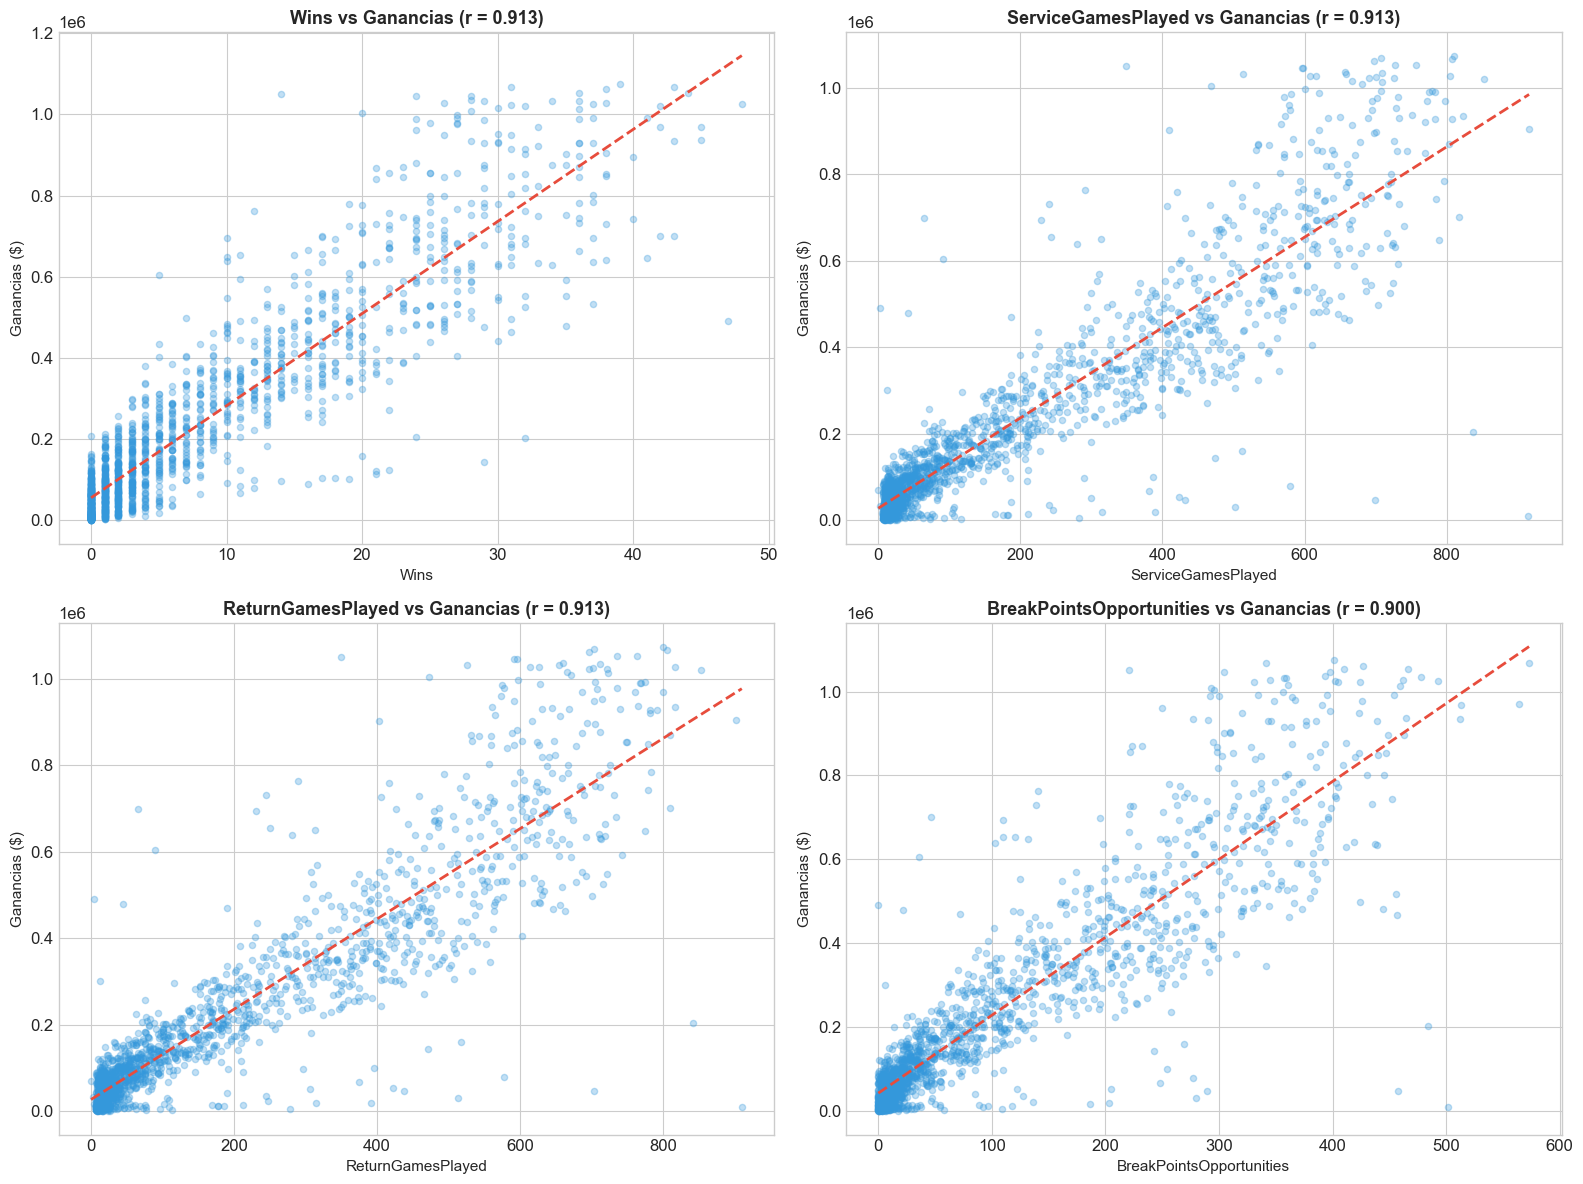

In [5]:
# Relacion de las 4 variables mas correlacionadas con Winnings
top4 = correlations.head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, var in enumerate(top4):
    axes[i].scatter(df[var], df['Winnings'], alpha=0.3, s=20, color='#3498db')
    # Linea de tendencia
    z = np.polyfit(df[var], df['Winnings'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[var].min(), df[var].max(), 100)
    axes[i].plot(x_line, p(x_line), color='#e74c3c', linewidth=2, linestyle='--')
    
    corr_val = df[var].corr(df['Winnings'])
    axes[i].set_title(f'{var} vs Ganancias (r = {corr_val:.3f})', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(var, fontsize=11)
    axes[i].set_ylabel('Ganancias ($)', fontsize=11)

plt.tight_layout()
plt.show()

## 3. Regresion Lineal Simple

Entrenamos un modelo de regresion simple usando la variable mas correlacionada (Wins) como unico predictor.

REGRESION SIMPLE: Wins -> Ganancias
  Coeficiente: $22,594.83 por victoria
  Intercepto: $54,899.01
  R² (train): 0.8322
  R² (test):  0.8418
  RMSE (test): $96,716


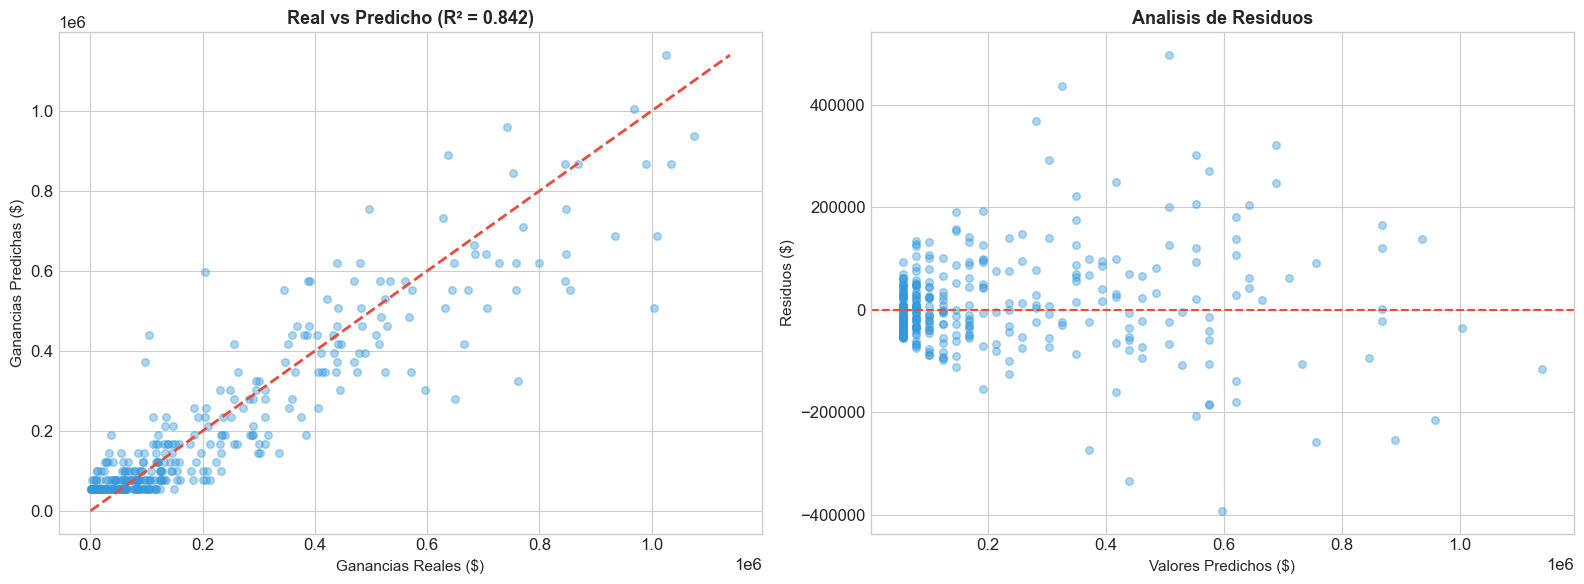

In [6]:
# Modelo 1: Regresion Simple (Wins -> Winnings)
X_simple = df[['Wins']]
y = df['Winnings']

X_train, X_test, y_train, y_test = train_test_split(X_simple, y, train_size=0.8, test_size=0.2, random_state=42)

model_simple = LinearRegression()
model_simple.fit(X_train, y_train)
y_pred_simple = model_simple.predict(X_test)

r2_train = model_simple.score(X_train, y_train)
r2_test = model_simple.score(X_test, y_test)

print("=" * 55)
print("REGRESION SIMPLE: Wins -> Ganancias")
print("=" * 55)
print(f"  Coeficiente: ${model_simple.coef_[0]:,.2f} por victoria")
print(f"  Intercepto: ${model_simple.intercept_:,.2f}")
print(f"  R² (train): {r2_train:.4f}")
print(f"  R² (test):  {r2_test:.4f}")
print(f"  RMSE (test): ${np.sqrt(mean_squared_error(y_test, y_pred_simple)):,.0f}")

# Visualizacion
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(y_test, y_pred_simple, alpha=0.4, color='#3498db', s=30)
min_val = min(y_test.min(), y_pred_simple.min())
max_val = max(y_test.max(), y_pred_simple.max())
axes[0].plot([min_val, max_val], [min_val, max_val], color='#e74c3c', linestyle='--', linewidth=2)
axes[0].set_title(f'Real vs Predicho (R² = {r2_test:.3f})', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Ganancias Reales ($)', fontsize=11)
axes[0].set_ylabel('Ganancias Predichas ($)', fontsize=11)

residuals = y_test - y_pred_simple
axes[1].scatter(y_pred_simple, residuals, alpha=0.4, color='#3498db', s=30)
axes[1].axhline(y=0, color='#e74c3c', linestyle='--', linewidth=1.5)
axes[1].set_title('Analisis de Residuos', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Valores Predichos ($)', fontsize=11)
axes[1].set_ylabel('Residuos ($)', fontsize=11)

plt.tight_layout()
plt.show()

## 4. Regresion Lineal Simple con Aces

Comparamos con otro predictor individual (Aces) para evaluar si una variable de servicio puede predecir las ganancias.

In [7]:
# Modelo 2: Regresion Simple (Aces -> Winnings)
X_aces = df[['Aces']]
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_aces, y, train_size=0.8, test_size=0.2, random_state=42)

model_aces = LinearRegression()
model_aces.fit(X_train2, y_train2)
y_pred_aces = model_aces.predict(X_test2)

r2_aces_train = model_aces.score(X_train2, y_train2)
r2_aces_test = model_aces.score(X_test2, y_test2)

print("=" * 55)
print("REGRESION SIMPLE: Aces -> Ganancias")
print("=" * 55)
print(f"  Coeficiente: ${model_aces.coef_[0]:,.2f} por ace")
print(f"  R² (train): {r2_aces_train:.4f}")
print(f"  R² (test):  {r2_aces_test:.4f}")
print(f"\n  Wins es un predictor {r2_test/r2_aces_test:.1f}x mejor que Aces.")

REGRESION SIMPLE: Aces -> Ganancias
  Coeficiente: $1,527.40 por ace
  R² (train): 0.6458
  R² (test):  0.5936

  Wins es un predictor 1.4x mejor que Aces.


## 5. Regresion Lineal Multiple

Usamos multiples variables para mejorar la prediccion. Seleccionamos las variables con mayor correlacion individual con las ganancias.

REGRESION MULTIPLE: 5 Variables -> Ganancias
  Features: ['Wins', 'Ranking', 'Aces', 'BreakPointsConverted', 'ServiceGamesWon']

  Coeficientes:
    Wins                      $   19,115.32
    Ranking                   $      -86.11
    Aces                      $      236.99
    BreakPointsConverted      $   18,647.51
    ServiceGamesWon           $   52,399.31
  Intercepto: $38,559.33

  R² (train): 0.8480
  R² (test):  0.8587
  RMSE (test): $91,391


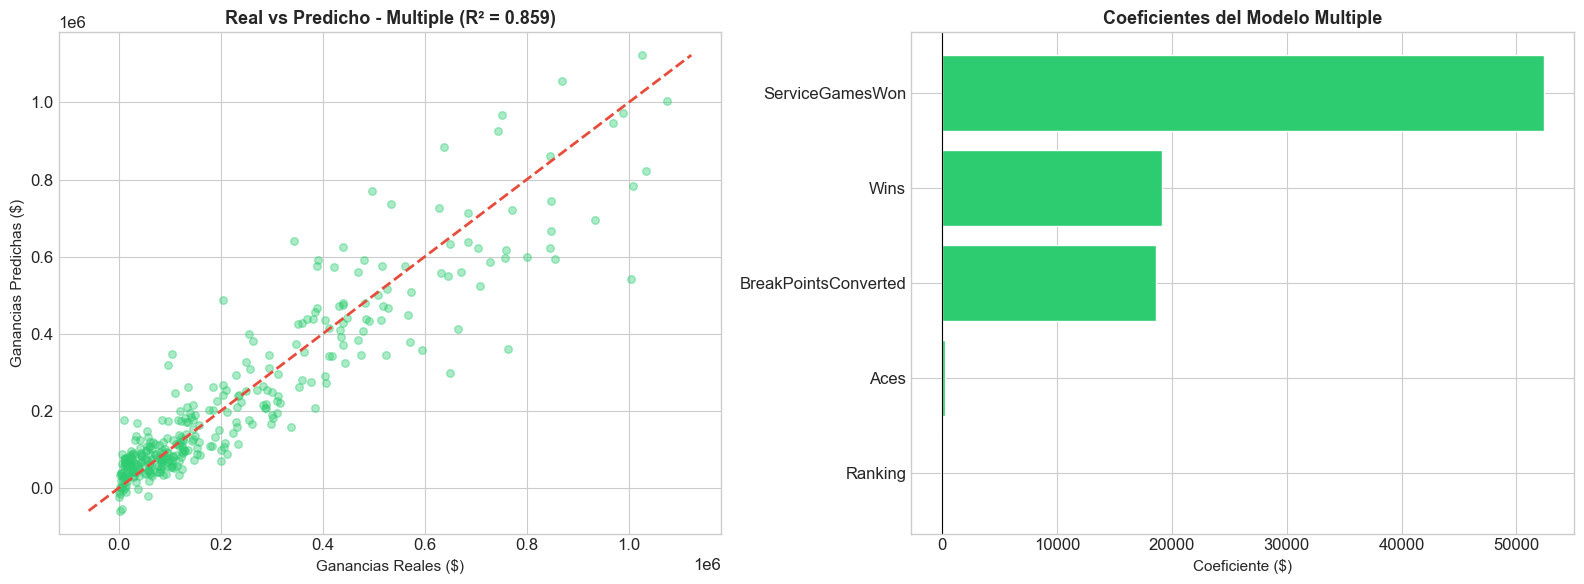

In [8]:
# Modelo 3: Regresion Multiple
features = ['Wins', 'Ranking', 'Aces', 'BreakPointsConverted', 'ServiceGamesWon']
X_multi = df[features]

X_train3, X_test3, y_train3, y_test3 = train_test_split(X_multi, y, train_size=0.8, test_size=0.2, random_state=42)

model_multi = LinearRegression()
model_multi.fit(X_train3, y_train3)
y_pred_multi = model_multi.predict(X_test3)

r2_multi_train = model_multi.score(X_train3, y_train3)
r2_multi_test = model_multi.score(X_test3, y_test3)

print("=" * 55)
print("REGRESION MULTIPLE: 5 Variables -> Ganancias")
print("=" * 55)
print(f"  Features: {features}")
print(f"\n  Coeficientes:")
for feat, coef in zip(features, model_multi.coef_):
    print(f"    {feat:<25} ${coef:>12,.2f}")
print(f"  Intercepto: ${model_multi.intercept_:,.2f}")
print(f"\n  R² (train): {r2_multi_train:.4f}")
print(f"  R² (test):  {r2_multi_test:.4f}")
print(f"  RMSE (test): ${np.sqrt(mean_squared_error(y_test3, y_pred_multi)):,.0f}")

# Visualizacion
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(y_test3, y_pred_multi, alpha=0.4, color='#2ecc71', s=30)
min_v = min(y_test3.min(), y_pred_multi.min())
max_v = max(y_test3.max(), y_pred_multi.max())
axes[0].plot([min_v, max_v], [min_v, max_v], color='#e74c3c', linestyle='--', linewidth=2)
axes[0].set_title(f'Real vs Predicho - Multiple (R² = {r2_multi_test:.3f})', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Ganancias Reales ($)', fontsize=11)
axes[0].set_ylabel('Ganancias Predichas ($)', fontsize=11)

# Importancia relativa (coeficientes normalizados)
coef_df = pd.DataFrame({'Feature': features, 'Coeficiente': model_multi.coef_})
coef_df = coef_df.sort_values('Coeficiente', key=abs, ascending=True)
colors_imp = ['#2ecc71' if c > 0 else '#e74c3c' for c in coef_df['Coeficiente']]
axes[1].barh(coef_df['Feature'], coef_df['Coeficiente'], color=colors_imp, edgecolor='white')
axes[1].set_title('Coeficientes del Modelo Multiple', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Coeficiente ($)', fontsize=11)
axes[1].axvline(x=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

## 6. Comparacion de Modelos

COMPARACION DE MODELOS
  Simple (Wins)          | 1 vars | R²=0.8418 | RMSE=$96,716
  Simple (Aces)          | 1 vars | R²=0.5936 | RMSE=$155,006
  Multiple (5 vars)      | 5 vars | R²=0.8587 | RMSE=$91,391


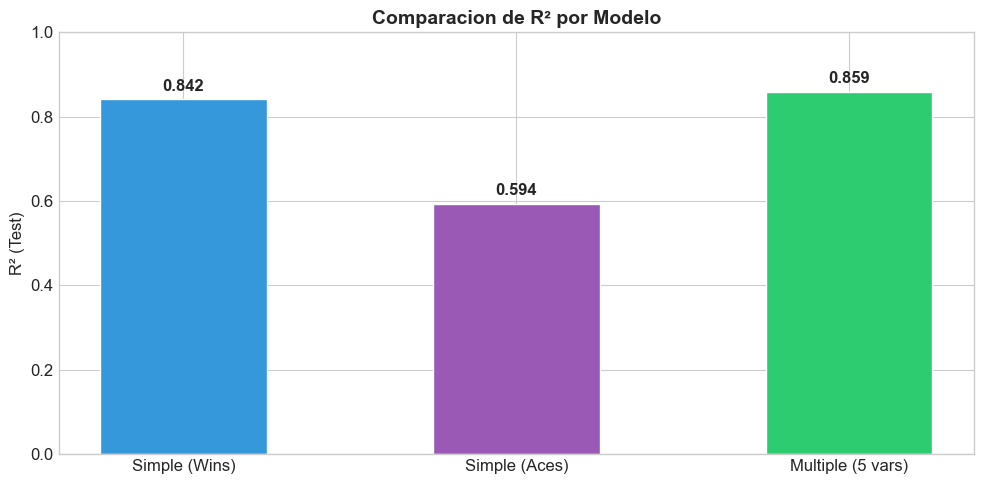

In [9]:
# Tabla comparativa
comparison = pd.DataFrame({
    'Modelo': ['Simple (Wins)', 'Simple (Aces)', 'Multiple (5 vars)'],
    'Variables': [1, 1, 5],
    'R² Train': [r2_train, r2_aces_train, r2_multi_train],
    'R² Test': [r2_test, r2_aces_test, r2_multi_test],
    'RMSE Test': [
        np.sqrt(mean_squared_error(y_test, y_pred_simple)),
        np.sqrt(mean_squared_error(y_test2, y_pred_aces)),
        np.sqrt(mean_squared_error(y_test3, y_pred_multi))
    ]
})

print("=" * 70)
print("COMPARACION DE MODELOS")
print("=" * 70)
for _, row in comparison.iterrows():
    print(f"  {row['Modelo']:<22} | {int(row['Variables'])} vars | R²={row['R² Test']:.4f} | RMSE=${row['RMSE Test']:,.0f}")
print("=" * 70)

# Visualizacion
fig, ax = plt.subplots(figsize=(10, 5))
colors_model = ['#3498db', '#9b59b6', '#2ecc71']
bars = ax.bar(comparison['Modelo'], comparison['R² Test'], color=colors_model, edgecolor='white', width=0.5)
ax.set_title('Comparacion de R² por Modelo', fontsize=14, fontweight='bold')
ax.set_ylabel('R² (Test)', fontsize=12)
ax.set_ylim(0, 1)
for bar, val in zip(bars, comparison['R² Test']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Conclusiones

### Hallazgos principales

1. **Wins es el mejor predictor individual** de las ganancias, con una correlacion fuerte y positiva. Esto tiene sentido intuitivo: ganar mas partidos genera mas prize money.

2. **El modelo multiple mejora significativamente** sobre la regresion simple. Al incluir Ranking, Aces, BreakPointsConverted y ServiceGamesWon, el modelo captura mas variabilidad en las ganancias.

3. **El Ranking tiene un coeficiente negativo**, lo cual es coherente: un menor ranking numerico indica una mejor posicion (Ranking 1 = mejor jugador), por lo que a menor ranking, mayores ganancias.

4. **Los Aces por si solos** son un predictor debil. Esto sugiere que la potencia del servicio no es suficiente para el exito economico; se necesita un juego completo.

### Limitaciones
- No se uso validacion cruzada (solo un split train/test)
- Los modelos asumen linealidad; la relacion puede ser no lineal
- Las ganancias tienen sesgo positivo; una transformacion logaritmica podria mejorar las predicciones

### Proximos pasos
- Aplicar transformacion logaritmica a Winnings
- Usar validacion cruzada (k-fold) para estimaciones mas robustas
- Probar modelos no lineales (Random Forest, Gradient Boosting)

---
*Analisis predictivo del rendimiento en tenis profesional, 1,721 registros, regresion lineal simple y multiple.*